In [1]:
!pip install pandas
!pip install scanpy
!pip install matplotlib
!pip install numpy
!pip install scikit-learn
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
distutils: /users/imbahndu/.local/lib/python3.9/site-packages
sysconfig: /users/imbahndu/.local/lib64/python3.9/site-packages
user = True
home = None
root = None
prefix = None
Defaulting to user installation because normal site-packages is not writeable
distutils: /users/imbahndu/.local/lib/python3.9/site-packages
sysconfig: /users/imbahndu/.local/lib64/python3.9/site-packages
user = True
home = None
root = None
prefix = None
Defaulting to user installation because normal site-packages is not writeable
distutils: /users/imbahndu/.local/lib/python3.9/site-packages
sysconfig: /users/imbahndu/.local/lib64/python3.9/site-packages
user = True
home = None
root = None
prefix = None
Defaulting to user installation because normal site-packages is not writeable
distutils: /users/imbahndu/.local/lib/python3.9/site-packages
sysconfig: /users/imbahndu/.local/lib64/python3.9/site-packages
user = True
home = None
root = Non

In [2]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as ppyplot
import numpy as np

In [3]:
adata = sc.read_h5ad("AD.h5ad")

In [4]:
adata.obs
adata.obs["disease"]

6-MTL_WM             leukoencephalopathy, diffuse hereditary, with ...
44-MTL_WM            leukoencephalopathy, diffuse hereditary, with ...
77-MTL_WM            leukoencephalopathy, diffuse hereditary, with ...
82-MTL_WM            leukoencephalopathy, diffuse hereditary, with ...
106-MTL_WM           leukoencephalopathy, diffuse hereditary, with ...
                                           ...                        
144432-Sample_140                                    Alzheimer disease
144468-Sample_140                                    Alzheimer disease
144471-Sample_140                                    Alzheimer disease
144511-Sample_140                                    Alzheimer disease
144588-Sample_140                                    Alzheimer disease
Name: disease, Length: 61747, dtype: category
Categories (3, object): ['Alzheimer disease', 'leukoencephalopathy, diffuse hereditary, with..., 'normal']

In [5]:

adata.var

,mt,ribo,hb,highly_variable,means,dispersions,dispersions_norm,gene_name,feature_is_filtered,gene_version,feature_name,feature_reference,feature_biotype,feature_length,feature_type
new_index,,,,,,,,,,,,,,,
ENSG00000186827,False,False,False,False,2.056692e-03,2.044141,0.651523,TNFRSF4,False,ENSG00000186827.11,TNFRSF4_ENSG00000186827,NCBITaxon:9606,gene,1039,protein_coding
ENSG00000186891,False,False,False,False,3.528555e-03,1.850113,0.415619,TNFRSF18,False,ENSG00000186891.14,TNFRSF18_ENSG00000186891,NCBITaxon:9606,gene,789,protein_coding
ENSG00000160072,False,False,False,True,1.710397e-01,1.959340,0.548420,ATAD3B,False,ENSG00000160072.20,ATAD3B_ENSG00000160072,NCBITaxon:9606,gene,3300,protein_coding
ENSG00000260179,False,False,False,False,1.390037e-03,1.191500,-0.385141,ENSG00000260179.1,False,ENSG00000260179.1,ENSG00000260179.1,NCBITaxon:9606,gene,1558,lncRNA
ENSG00000234396,False,False,False,False,7.698351e-03,1.369916,-0.168218,ENSG00000234396.3,False,ENSG00000234396.3,ENSG00000234396.3,NCBITaxon:9606,gene,326,lncRNA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000271254,False,False,False,True,9.964368e-02,2.025638,0.629027,ENSG00000271254.7,False,ENSG00000271254.7,ENSG00000271254.7,NCBITaxon:9606,gene,2922,protein_coding
ENSG00000275987,False,False,False,False,2.032705e-04,0.486198,-1.242666,U1-4,False,ENSG00000275987.1,U1_ENSG00000275987,NCBITaxon:9606,gene,144,snRNA
ENSG00000268674,False,False,False,False,2.704107e-05,0.512661,-1.210492,ENSG00000268674.2,False,ENSG00000268674.2,ENSG00000268674.2,NCBITaxon:9606,gene,510,protein_coding


In [6]:
adata.var["Mito"] = adata.var_names.str.startswith("MT")
sc.pp.calculate_qc_metrics(adata, qc_vars=["Mito"], inplace=True, percent_top=[50])

In [7]:
adata.obs.columns

Index(['APOE', 'Brain.Region', 'SORT', 'Braak.stage', 'Amyloid',
       'Brain.weight', 'PMI.hr.', 'RIN', 'Gray.vs.White', 'n_genes_by_counts',
       'total_counts', 'pct_counts_ribo', 'pct_counts_hb', 'pct_counts_mt',
       'n_counts', 'n_genes', '20_leiden_1.0', 'Sample', 'Molecule',
       'single_or_paired_end', 'Instrument', 'organism_ontology_term_id',
       'donor_id', 'development_stage_ontology_term_id',
       'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id',
       'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id',
       'cell_type_ontology_term_id', 'assay_ontology_term_id',
       'suspension_type', 'is_primary_data', 'cell_type', 'assay', 'disease',
       'organism', 'sex', 'tissue', 'self_reported_ethnicity',
       'development_stage', 'observation_joinid', 'log1p_n_genes_by_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes', 'total_counts_Mito',
       'log1p_total_counts_Mito', 'pct_counts_Mito'],
      dtype='

In [8]:
adata.var

,mt,ribo,hb,highly_variable,means,dispersions,dispersions_norm,gene_name,feature_is_filtered,gene_version,...,feature_biotype,feature_length,feature_type,Mito,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
new_index,,,,,,,,,,,,,,,,,,,,,
ENSG00000186827,False,False,False,False,2.056692e-03,2.044141,0.651523,TNFRSF4,False,ENSG00000186827.11,...,gene,1039,protein_coding,False,56,0.000878,0.000877,99.909307,54.191319,4.010806
ENSG00000186891,False,False,False,False,3.528555e-03,1.850113,0.415619,TNFRSF18,False,ENSG00000186891.14,...,gene,789,protein_coding,False,105,0.001559,0.001558,99.829951,96.258057,4.577368
ENSG00000160072,False,False,False,True,1.710397e-01,1.959340,0.548420,ATAD3B,False,ENSG00000160072.20,...,gene,3300,protein_coding,False,4843,0.079652,0.076638,92.156704,4918.245117,8.500911
ENSG00000260179,False,False,False,False,1.390037e-03,1.191500,-0.385141,ENSG00000260179.1,False,ENSG00000260179.1,...,gene,1558,lncRNA,False,38,0.000664,0.000664,99.938459,40.986538,3.737349
ENSG00000234396,False,False,False,False,7.698351e-03,1.369916,-0.168218,ENSG00000234396.3,False,ENSG00000234396.3,...,gene,326,lncRNA,False,265,0.003792,0.003785,99.570829,234.150528,5.460226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000271254,False,False,False,True,9.964368e-02,2.025638,0.629027,ENSG00000271254.7,False,ENSG00000271254.7,...,gene,2922,protein_coding,False,2847,0.045196,0.044205,95.389250,2790.737793,7.934420
ENSG00000275987,False,False,False,False,2.032705e-04,0.486198,-1.242666,U1-4,False,ENSG00000275987.1,...,gene,144,snRNA,False,10,0.000125,0.000125,99.983805,7.712062,2.164709
ENSG00000268674,False,False,False,False,2.704107e-05,0.512661,-1.210492,ENSG00000268674.2,False,ENSG00000268674.2,...,gene,510,protein_coding,False,1,0.000016,0.000016,99.998380,0.981977,0.684095


In [9]:
adata.var["Mito"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, percent_top=[50], qc_vars=["Mito"], inplace=True)

In [10]:
sc.pp.filter_genes(adata, min_cells=200)

In [11]:
sc.pp.filter_cells(adata, min_genes=100)

In [12]:
adata.var

,mt,ribo,hb,highly_variable,means,dispersions,dispersions_norm,gene_name,feature_is_filtered,gene_version,...,feature_length,feature_type,Mito,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells
new_index,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,False,False,False,True,0.171040,1.959340,0.548420,ATAD3B,False,ENSG00000160072.20,...,3300,protein_coding,False,4843,0.079652,0.076638,92.156704,4918.245117,8.500911,4843
ENSG00000234396,False,False,False,False,0.007698,1.369916,-0.168218,ENSG00000234396.3,False,ENSG00000234396.3,...,326,lncRNA,False,265,0.003792,0.003785,99.570829,234.150528,5.460226,265
ENSG00000225972,False,False,False,False,0.012065,1.924090,0.505562,MTND1P23,False,ENSG00000225972.1,...,372,unprocessed_pseudogene,False,232,0.004664,0.004653,99.624273,287.974213,5.666337,232
ENSG00000142611,False,False,False,False,0.887664,2.111904,0.431578,PRDM16,False,ENSG00000142611.17,...,3730,protein_coding,False,16099,0.438293,0.363457,73.927478,27063.226562,10.205968,16099
ENSG00000131584,False,False,False,True,0.466380,2.199229,0.967132,ACAP3,False,ENSG00000131584.19,...,819,protein_coding,False,11281,0.218978,0.198013,81.730286,13521.191406,9.512088,11281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000273748,False,False,False,False,0.583982,1.835337,-0.330209,ENSG00000273748.1,False,ENSG00000273748.1,...,372,protein_coding,False,16669,0.323217,0.280066,73.004356,19957.730469,9.901422,16669
ENSG00000277196,False,False,False,False,0.072129,0.978282,-0.644377,ENSG00000277196.4,False,ENSG00000277196.4,...,2197,protein_coding,False,2682,0.040307,0.039516,95.656469,2488.856934,7.819981,2682
ENSG00000278817,False,False,False,False,0.029132,1.604926,0.117515,ENSG00000278817.1,False,ENSG00000278817.1,...,1213,protein_coding,False,925,0.013963,0.013866,98.501952,862.145935,6.760584,925


In [13]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [14]:
sc.pp.highly_variable_genes(adata, flavor='seurat', n_top_genes=2000)
adata = adata[:, adata.var['highly_variable']]


/users/imbahndu/.local/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


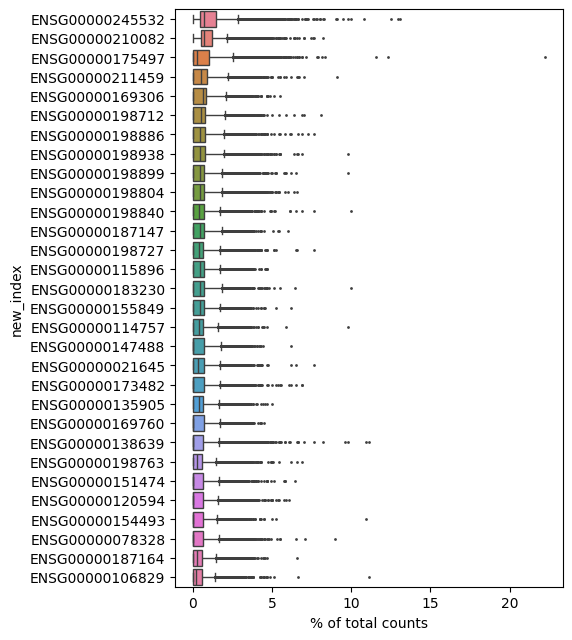

In [15]:
sc.pl.highest_expr_genes(adata)

In [16]:
sc.pp.scale(adata)

In [17]:
sc.pp.pca(adata)
sc.pp.normalize_total(adata, exclude_highly_expressed = True, inplace=True, target_sum = 1e4)

/users/imbahndu/.local/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


In [18]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)

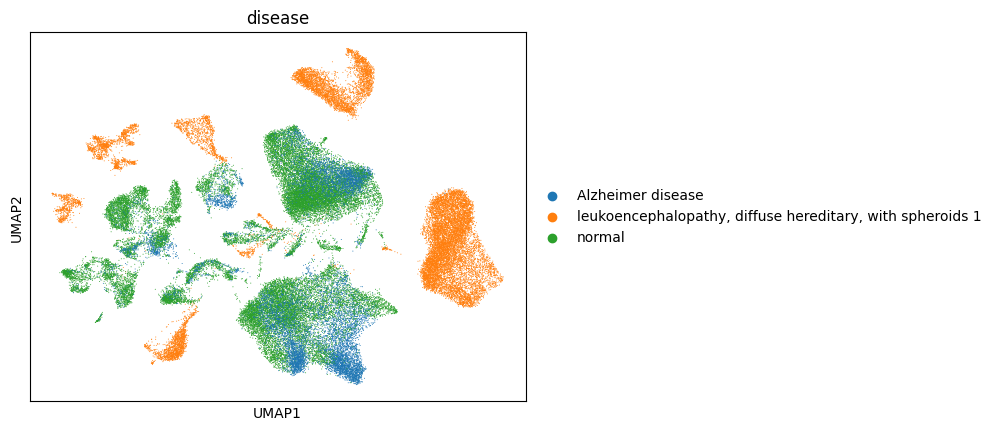

In [19]:
sc.pl.umap(adata, color="disease")

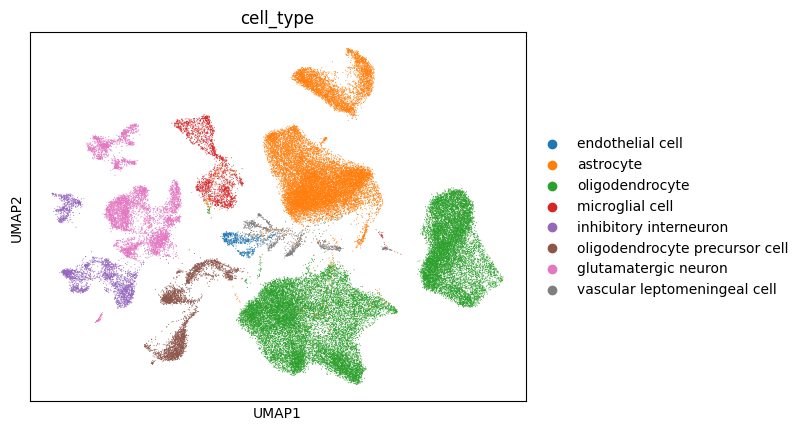

In [20]:
sc.pl.umap(adata, color="cell_type")

In [21]:
nan_values = adata.obs.isnull().any(axis=1).copy()

In [22]:
nan_values.count

<bound method Series.count of 6-MTL_WM             False
44-MTL_WM            False
77-MTL_WM            False
82-MTL_WM            False
106-MTL_WM           False
                     ...  
144432-Sample_140     True
144468-Sample_140     True
144471-Sample_140     True
144511-Sample_140     True
144588-Sample_140     True
Length: 61745, dtype: bool>

In [23]:
new_adata = adata[~nan_values].copy()

In [24]:
new_adata.obs

,APOE,Brain.Region,SORT,Braak.stage,Amyloid,Brain.weight,PMI.hr.,RIN,Gray.vs.White,n_genes_by_counts,...,tissue,self_reported_ethnicity,development_stage,observation_joinid,log1p_n_genes_by_counts,log1p_total_counts,pct_counts_in_top_50_genes,total_counts_Mito,log1p_total_counts_Mito,pct_counts_Mito
6-MTL_WM,E3/E4,Medial temporal,DAPI,IV,C1,1355.0,24.0,4.3,wm,991,...,white matter of temporal lobe,European,72-year-old stage,0b*^?3z<35,6.899723,7.689979,8.691307,0.0,0.0,0.0
44-MTL_WM,E3/E4,Medial temporal,DAPI,IV,C1,1355.0,24.0,4.3,wm,760,...,white matter of temporal lobe,European,72-year-old stage,rRUZAD#H$=,6.634633,7.534247,10.473275,0.0,0.0,0.0
77-MTL_WM,E3/E4,Medial temporal,DAPI,IV,C1,1355.0,24.0,4.3,wm,580,...,white matter of temporal lobe,European,72-year-old stage,;E{vC#|}Wl,6.364751,7.378717,12.168860,0.0,0.0,0.0
82-MTL_WM,E3/E4,Medial temporal,DAPI,IV,C1,1355.0,24.0,4.3,wm,2708,...,white matter of temporal lobe,European,72-year-old stage,vYCKi%e9%T,7.904335,8.166871,5.095474,0.0,0.0,0.0
106-MTL_WM,E3/E4,Medial temporal,DAPI,IV,C1,1355.0,24.0,4.3,wm,779,...,white matter of temporal lobe,European,72-year-old stage,r<T9CWQrcN,6.659294,7.552385,10.081000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148676-Sample_46,E3/E3,Frontal,Pax6/NeuNneg,IV,C1,1375.0,19.5,5.2,gray/wm,5198,...,prefrontal cortex,unknown,83-year-old stage,cds5th<ZK7,8.556222,8.341575,4.231328,0.0,0.0,0.0
148736-Sample_46,E3/E3,Frontal,Pax6/NeuNneg,IV,C1,1375.0,19.5,5.2,gray/wm,2317,...,prefrontal cortex,unknown,83-year-old stage,n&lNii}m8c,7.748460,8.120696,5.205448,0.0,0.0,0.0
148783-Sample_46,E3/E3,Frontal,Pax6/NeuNneg,IV,C1,1375.0,19.5,5.2,gray/wm,2422,...,prefrontal cortex,unknown,83-year-old stage,MaujRC@Ki6,7.792762,8.132295,5.066612,0.0,0.0,0.0
148846-Sample_46,E3/E3,Frontal,Pax6/NeuNneg,IV,C1,1375.0,19.5,5.2,gray/wm,4246,...,prefrontal cortex,unknown,83-year-old stage,F*G&mS+~*4,8.353968,8.288458,4.382662,0.0,0.0,0.0


In [25]:
print(new_adata.obs["disease"].value_counts())

disease
leukoencephalopathy, diffuse hereditary, with spheroids 1    19162
normal                                                        7962
Alzheimer disease                                             5190
Name: count, dtype: int64


In [26]:
oligos_subset = adata[adata.obs["cell_type"]=="oligodendrocyte"]

In [27]:
oligos_subset.obs

,APOE,Brain.Region,SORT,Braak.stage,Amyloid,Brain.weight,PMI.hr.,RIN,Gray.vs.White,n_genes_by_counts,...,tissue,self_reported_ethnicity,development_stage,observation_joinid,log1p_n_genes_by_counts,log1p_total_counts,pct_counts_in_top_50_genes,total_counts_Mito,log1p_total_counts_Mito,pct_counts_Mito
6-MTL_WM,E3/E4,Medial temporal,DAPI,IV,C1,1355.0,24.0,4.3,wm,991,...,white matter of temporal lobe,European,72-year-old stage,0b*^?3z<35,6.899723,7.689979,8.691307,0.0,0.0,0.0
44-MTL_WM,E3/E4,Medial temporal,DAPI,IV,C1,1355.0,24.0,4.3,wm,760,...,white matter of temporal lobe,European,72-year-old stage,rRUZAD#H$=,6.634633,7.534247,10.473275,0.0,0.0,0.0
77-MTL_WM,E3/E4,Medial temporal,DAPI,IV,C1,1355.0,24.0,4.3,wm,580,...,white matter of temporal lobe,European,72-year-old stage,;E{vC#|}Wl,6.364751,7.378717,12.168860,0.0,0.0,0.0
106-MTL_WM,E3/E4,Medial temporal,DAPI,IV,C1,1355.0,24.0,4.3,wm,779,...,white matter of temporal lobe,European,72-year-old stage,r<T9CWQrcN,6.659294,7.552385,10.081000,0.0,0.0,0.0
126-MTL_WM,E3/E4,Medial temporal,DAPI,IV,C1,1355.0,24.0,4.3,wm,2386,...,white matter of temporal lobe,European,72-year-old stage,xt{eA>*-n_,7.777793,8.096650,5.544508,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144337-Sample_140,E3/E4,Frontal,Pax6/NeuNneg,III,Diffuse plaques,NaN,10.0,6.1,gray/wm,3553,...,prefrontal cortex,unknown,81-year-old stage,3Z<xyGh{N!,8.175829,8.261338,4.504398,0.0,0.0,0.0
144345-Sample_140,E3/E4,Frontal,Pax6/NeuNneg,III,Diffuse plaques,NaN,10.0,6.1,gray/wm,2167,...,prefrontal cortex,unknown,81-year-old stage,c0+G|(adYP,7.681560,8.084967,5.490188,0.0,0.0,0.0
144401-Sample_140,E3/E4,Frontal,Pax6/NeuNneg,III,Diffuse plaques,NaN,10.0,6.1,gray/wm,2725,...,prefrontal cortex,unknown,81-year-old stage,wziL<se?K!,7.910591,8.160071,5.040737,0.0,0.0,0.0
144468-Sample_140,E3/E4,Frontal,Pax6/NeuNneg,III,Diffuse plaques,NaN,10.0,6.1,gray/wm,1282,...,prefrontal cortex,unknown,81-year-old stage,B}fZT(i#NE,7.156956,7.867307,6.635993,0.0,0.0,0.0


In [28]:
oligos_subset.obs["cell_type"]

6-MTL_WM             oligodendrocyte
44-MTL_WM            oligodendrocyte
77-MTL_WM            oligodendrocyte
106-MTL_WM           oligodendrocyte
126-MTL_WM           oligodendrocyte
                          ...       
144337-Sample_140    oligodendrocyte
144345-Sample_140    oligodendrocyte
144401-Sample_140    oligodendrocyte
144468-Sample_140    oligodendrocyte
144511-Sample_140    oligodendrocyte
Name: cell_type, Length: 26880, dtype: category
Categories (1, object): ['oligodendrocyte']

In [29]:
print(oligos_subset.X)

[[-0.43459746 -0.06065332 -0.351528   ... -0.06672466 -0.17637646
  -0.05960915]
 [-0.43459746 -0.06065332 -0.351528   ... -0.06672466 -0.17637646
  -0.05960915]
 [-0.43459746 -0.06065332 -0.351528   ... -0.06672466 -0.17637646
  -0.05960915]
 ...
 [-0.43459746 -0.06065332 -0.351528   ... -0.06672466 -0.17637646
  -0.05960915]
 [-0.43459746 -0.06065332 -0.351528   ... -0.06672466 -0.17637646
  -0.05960915]
 [-0.43459746 -0.06065332  1.539564   ... -0.06672466 -0.17637646
  -0.05960915]]


In [30]:
new_adata.obs["disease"]

6-MTL_WM            leukoencephalopathy, diffuse hereditary, with ...
44-MTL_WM           leukoencephalopathy, diffuse hereditary, with ...
77-MTL_WM           leukoencephalopathy, diffuse hereditary, with ...
82-MTL_WM           leukoencephalopathy, diffuse hereditary, with ...
106-MTL_WM          leukoencephalopathy, diffuse hereditary, with ...
                                          ...                        
148676-Sample_46                                    Alzheimer disease
148736-Sample_46                                    Alzheimer disease
148783-Sample_46                                    Alzheimer disease
148846-Sample_46                                    Alzheimer disease
148920-Sample_46                                    Alzheimer disease
Name: disease, Length: 32314, dtype: category
Categories (3, object): ['Alzheimer disease', 'leukoencephalopathy, diffuse hereditary, with..., 'normal']

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance



In [32]:
X_data = new_adata.X
y_label = new_adata.obs["disease"]
X_train, X_test, y_train, y_test = train_test_split(X_data, y_label, test_size=0.33, stratify=y_label)
model = LogisticRegression(solver='lbfgs', C=0.1, class_weight="balanced", max_iter=1000)
model.fit(X_train, y_train)
class_label_predictions = model.predict_proba(X_test)
pred = model.predict(X_test)
acc_score = accuracy_score(y_test, pred)

print(acc_score)


0.9913728432108027


In [33]:
conf_matrix = confusion_matrix(y_test, pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[1672    1   40]
 [   5 6297   22]
 [  22    2 2603]]


In [34]:
class_report = classification_report(y_test, pred)
print("Classification Report:")
print(class_report)

Classification Report:
                                                           precision    recall  f1-score   support

                                        Alzheimer disease       0.98      0.98      0.98      1713
leukoencephalopathy, diffuse hereditary, with spheroids 1       1.00      1.00      1.00      6324
                                                   normal       0.98      0.99      0.98      2627

                                                 accuracy                           0.99     10664
                                                macro avg       0.99      0.99      0.99     10664
                                             weighted avg       0.99      0.99      0.99     10664



Defaulting to user installation because normal site-packages is not writeable
distutils: /users/imbahndu/.local/lib/python3.9/site-packages
sysconfig: /users/imbahndu/.local/lib64/python3.9/site-packages
user = True
home = None
root = None
prefix = None


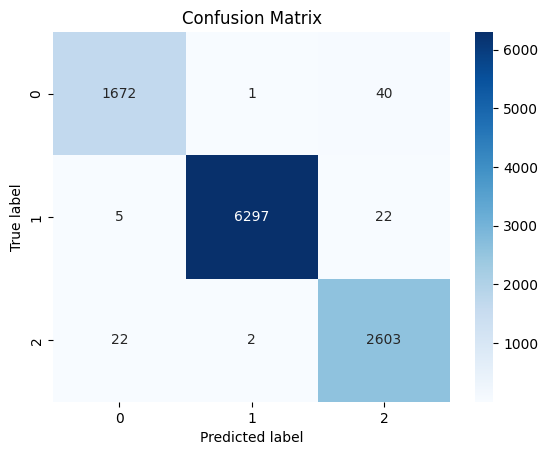

In [35]:
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

In [36]:
sfm = SelectFromModel(model, prefit=True, threshold="mean")  
X_train_selected = sfm.transform(X_train)
X_test_selected = sfm.transform(X_test)

print(f"Selected {X_train_selected.shape[1]} features out of {X_train.shape[1]}")

Selected 716 features out of 2000


In [37]:
selected_mask = sfm.get_support()  
selected_genes = new_adata.var_names[selected_mask]  
print(selected_genes)
print(type(selected_genes))

Index(['ENSG00000230021', 'ENSG00000248527', 'ENSG00000232423',
       'ENSG00000157978', 'ENSG00000084628', 'ENSG00000162490',
       'ENSG00000237928', 'ENSG00000226419', 'ENSG00000116147',
       'ENSG00000234810',
       ...
       'ENSG00000147065', 'ENSG00000198223', 'ENSG00000233067',
       'ENSG00000225470', 'ENSG00000130066', 'ENSG00000157514',
       'ENSG00000169933', 'ENSG00000234795', 'ENSG00000286217',
       'ENSG00000278847'],
      dtype='object', name='new_index', length=716)
<class 'pandas.core.indexes.base.Index'>


In [38]:
selected = list(selected_genes)

# Extract gene names
selected_gene_symbols = new_adata.var.loc[selected_genes, "gene_name"]

print(selected_gene_symbols)


new_index
ENSG00000230021    ENSG00000230021.10
ENSG00000248527              MTATP6P1
ENSG00000232423               PRAMEF6
ENSG00000157978               LDLRAP1
ENSG00000084628                NKAIN1
                          ...        
ENSG00000157514               TSC22D3
ENSG00000169933                FRMPD4
ENSG00000234795               RFTN1P1
ENSG00000286217             LINC00279
ENSG00000278847     ENSG00000278847.1
Name: gene_name, Length: 716, dtype: object


In [49]:
#Talk to Majoie abt accuracy 
      #Overfit --> maybe not removing the NAN values, 
      #Reading papers on a similar papers -->

#Create a new dataset with these filtered genes
selected_genes = list(set(selected_genes).intersection(set(adata.var_names)))
selected_genes



#Combine this dataset with the cereb data 

#Find genes if they correlate with cereb data

#Train maybe a neural net for this? or do feature importance with SHAP?

['ENSG00000143476',
 'ENSG00000227906',
 'ENSG00000054690',
 'ENSG00000162490',
 'ENSG00000050555',
 'ENSG00000270757',
 'ENSG00000149212',
 'ENSG00000253619',
 'ENSG00000026508',
 'ENSG00000136960',
 'ENSG00000226994',
 'ENSG00000154655',
 'ENSG00000285638',
 'ENSG00000248901',
 'ENSG00000198121',
 'ENSG00000253300',
 'ENSG00000100142',
 'ENSG00000187889',
 'ENSG00000231416',
 'ENSG00000231079',
 'ENSG00000253311',
 'ENSG00000137270',
 'ENSG00000273269',
 'ENSG00000161016',
 'ENSG00000183032',
 'ENSG00000099797',
 'ENSG00000231971',
 'ENSG00000011007',
 'ENSG00000179066',
 'ENSG00000256971',
 'ENSG00000105339',
 'ENSG00000242880',
 'ENSG00000103550',
 'ENSG00000115484',
 'ENSG00000265480',
 'ENSG00000173068',
 'ENSG00000230479',
 'ENSG00000233005',
 'ENSG00000091513',
 'ENSG00000236197',
 'ENSG00000184672',
 'ENSG00000196951',
 'ENSG00000197956',
 'ENSG00000113578',
 'ENSG00000088827',
 'ENSG00000237491',
 'ENSG00000168071',
 'ENSG00000181072',
 'ENSG00000175768',
 'ENSG00000196141',


In [52]:
adata_combined = new_adata[:, selected_genes].copy()

In [53]:
adata_combined

AnnData object with n_obs × n_vars = 32314 × 716
    obs: 'APOE', 'Brain.Region', 'SORT', 'Braak.stage', 'Amyloid', 'Brain.weight', 'PMI.hr.', 'RIN', 'Gray.vs.White', 'n_genes_by_counts', 'total_counts', 'pct_counts_ribo', 'pct_counts_hb', 'pct_counts_mt', 'n_counts', 'n_genes', '20_leiden_1.0', 'Sample', 'Molecule', 'single_or_paired_end', 'Instrument', 'organism_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'total_counts_Mito', 'log1p_total_counts_Mito', 'pct_counts_Mito'
    var: 'mt', 'ribo', 'hb', 'highly_variable', 'means'

In [55]:
adata_combined.var

,mt,ribo,hb,highly_variable,means,dispersions,dispersions_norm,gene_name,feature_is_filtered,gene_version,...,Mito,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,mean,std
new_index,,,,,,,,,,,,,,,,,,,,,
ENSG00000143476,False,False,False,True,0.353461,2.894729,5.330721,DTL,False,ENSG00000143476.18,...,False,3544,0.085977,0.082480,94.260450,5308.822754,8.577313,3544,0.099681,0.450068
ENSG00000227906,False,False,False,True,0.230298,2.440070,2.423075,SNAP25-AS1,False,ENSG00000227906.9,...,False,3651,0.065661,0.063595,94.087162,4054.356934,8.307794,3651,0.084154,0.369951
ENSG00000054690,False,False,False,True,1.382041,2.149572,1.530642,PLEKHH1,False,ENSG00000054690.14,...,False,24344,0.784186,0.578962,60.574603,48421.019531,10.787710,24344,0.786970,1.033903
ENSG00000162490,False,False,False,True,0.024429,2.347672,1.374279,DRAXIN,False,ENSG00000162490.7,...,False,375,0.006605,0.006583,99.392683,407.848541,6.013345,375,0.008522,0.118331
ENSG00000050555,False,False,False,True,0.089697,2.466249,1.754707,LAMC3,False,ENSG00000050555.19,...,False,1178,0.023838,0.023559,98.092215,1471.939209,7.295015,1178,0.028596,0.225879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000170396,False,False,False,True,0.607005,2.210718,1.864053,ZNF804A,False,ENSG00000170396.9,...,False,8295,0.246276,0.220160,86.566149,15206.790039,9.629563,8295,0.244306,0.651755
ENSG00000286217,False,False,False,True,0.190078,2.486821,2.637177,LINC00279,False,ENSG00000286217.2,...,False,2131,0.050659,0.049417,96.548820,3128.028809,8.048478,2131,0.059298,0.336204
ENSG00000172554,False,False,False,True,0.243634,2.377722,2.137546,SNTG2,False,ENSG00000172554.12,...,False,3772,0.075041,0.072359,93.891201,4633.573242,8.441299,3772,0.089544,0.383285


In [57]:
cereb_data = sc.read_h5ad("cereb.h5ad")

In [66]:
cereb_data.var

,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type,n_cells
ENSG00000078369,False,GNB1_ENSG00000078369,NCBITaxon:9606,gene,2750,protein_coding,84057
ENSG00000171735,False,CAMTA1_ENSG00000171735,NCBITaxon:9606,gene,2142,protein_coding,115417
ENSG00000049246,False,PER3_ENSG00000049246,NCBITaxon:9606,gene,1524,protein_coding,39125
ENSG00000142599,False,RERE_ENSG00000142599,NCBITaxon:9606,gene,852,protein_coding,135904
ENSG00000048707,False,VPS13D_ENSG00000048707,NCBITaxon:9606,gene,1303,protein_coding,55968
...,...,...,...,...,...,...,...
ENSG00000144230,False,GPR17_ENSG00000144230,NCBITaxon:9606,gene,1628,protein_coding,619
ENSG00000107317,False,PTGDS_ENSG00000107317,NCBITaxon:9606,gene,638,protein_coding,14093
ENSG00000100362,False,PVALB_ENSG00000100362,NCBITaxon:9606,gene,540,protein_coding,4685
ENSG00000168329,False,CX3CR1_ENSG00000168329,NCBITaxon:9606,gene,3128,protein_coding,1205


In [59]:
both_data = cereb_data.concatenate(adata_combined, join="outer")

/tmp/ipykernel_414515/776380407.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  both_data = cereb_data.concatenate(adata_combined, join="outer")
/users/imbahndu/.local/lib/python3.9/site-packages/anndata/_core/merge.py:1358: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(


In [69]:
genes_both = list(set(selected_genes).intersection(set(both_data.var_names)))
len(genes_both)

716

In [60]:
both_data

AnnData object with n_obs × n_vars = 115176 × 1343
    obs: 'orig_cluster', 'orig_sub_cluster', 'broad_lineage', 'author_cell_type', 'dev_state', 'subtype', 'precisest_label', 'tissue_id', 'batch', 'size_factor', 'donor_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'is_primary_data', 'author_stage', 'tissue_fragment', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_counts', 'n_genes', 'APOE', 'Brain.Region', 'SORT', 'Braak.stage', 'Amyloid', 'Brain.weight', 'PMI.hr.', 'RIN', 'Gray.vs.White', 'n_genes_by_counts', 'total_counts', 'pct_counts_ribo', 'pct_counts_hb', 'pct_counts_mt', '20_leiden_1.0', 'Sample', 'Molecule', 'single_or_paired_end', 'Instrument', 'log1p_n_g

In [62]:
sc.pp.neighbors(both_data, n_neighbors=10, n_pcs=40)
sc.tl.umap(both_data)

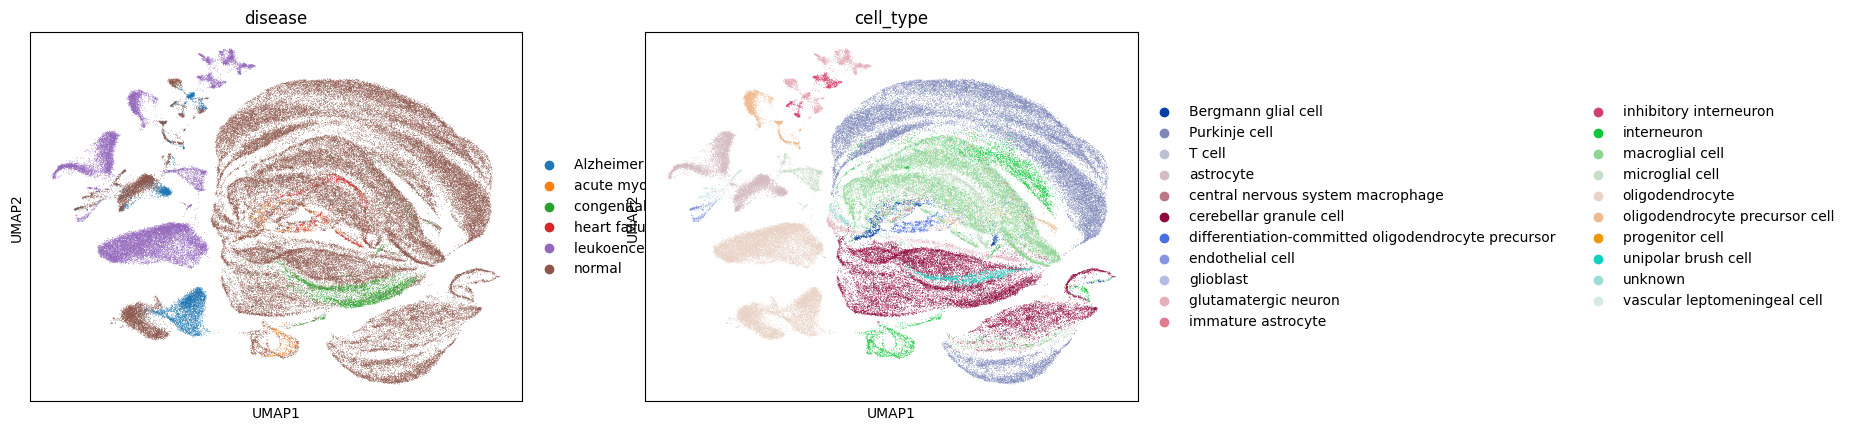

In [65]:
sc.pl.umap(both_data, color=["disease", "cell_type"])